# DTAAD — Dual TCN-Attention Networks for Anomaly Detection
**Paper:** Knowledge-Based Systems 295 (2024) 111849

> **실행법:** 런타임 → 런타임 유형 변경 → T4 GPU → 런타임 → 모두 실행 (Ctrl+F9)

## 0. 패키지 설치

In [ ]:
!pip install -q scipy scikit-learn
import torch, math, copy
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy.stats import genpareto
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
print(f"PyTorch {torch.__version__} | {'GPU: '+torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


PyTorch 2.10.0+cu128 | GPU: Tesla T4


## 1. Model

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Local TCN — Causal Convolution  (Fig.2, Eq.14)
# weight_norm 제거: deepcopy 호환성 문제 방지
# ══════════════════════════════════════════════════════════════════
class CausalConv1d(nn.Module):
    def __init__(self, in_c, out_c, kernel):
        super().__init__()
        self.left_pad = kernel - 1
        self.conv = nn.Conv1d(in_c, out_c, kernel)
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='leaky_relu')

    def forward(self, x):          # x: (B, C, T)
        return self.conv(F.pad(x, (self.left_pad, 0)))


class LocalTCNBlock(nn.Module):
    def __init__(self, ch, kernel, drop=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(ch, ch, kernel)
        self.conv2 = CausalConv1d(ch, ch, kernel)
        self.norm1 = nn.LayerNorm(ch)
        self.norm2 = nn.LayerNorm(ch)
        self.drop  = nn.Dropout(drop)
        self.act   = nn.LeakyReLU(0.01)

    def forward(self, x):          # x: (B, T, C)
        res = x
        o = self.drop(self.act(self.norm1(
                self.conv1(x.permute(0,2,1)).permute(0,2,1))))
        o = self.drop(self.act(self.norm2(
                self.conv2(o.permute(0,2,1)).permute(0,2,1))))
        return o + res


class LocalTCN(nn.Module):
    def __init__(self, in_dim, hid, kernel=3, n_layers=2, drop=0.2):
        super().__init__()
        self.proj   = nn.Linear(in_dim, hid)
        self.blocks = nn.ModuleList(
            [LocalTCNBlock(hid, kernel, drop) for _ in range(n_layers)])

    def forward(self, x):
        o = self.proj(x)
        for b in self.blocks:
            o = b(o)
        return o


# ══════════════════════════════════════════════════════════════════
# Global TCN — Dilated Convolution  (Fig.3, Eq.15-20)
# ══════════════════════════════════════════════════════════════════
def min_dilated_layers(seq_len, kernel=3, base=2):
    if seq_len <= 1:
        return 1
    val = (seq_len - 1) * (base - 1) / (kernel - 1) + 1
    return max(1, math.ceil(math.log(val, base)))


class DilatedConv1d(nn.Module):
    def __init__(self, ch, kernel, dilation):
        super().__init__()
        self.left_pad = dilation * (kernel - 1)
        self.conv = nn.Conv1d(ch, ch, kernel, dilation=dilation)
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='leaky_relu')

    def forward(self, x):          # x: (B, C, T)
        return self.conv(F.pad(x, (self.left_pad, 0)))


class GlobalTCNBlock(nn.Module):
    def __init__(self, ch, kernel, dilation, drop=0.2):
        super().__init__()
        self.conv1 = DilatedConv1d(ch, kernel, dilation)
        self.conv2 = DilatedConv1d(ch, kernel, dilation)
        self.norm1 = nn.LayerNorm(ch)
        self.norm2 = nn.LayerNorm(ch)
        self.drop  = nn.Dropout(drop)
        self.act   = nn.LeakyReLU(0.01)

    def forward(self, x):          # x: (B, T, C)
        res = x
        o = self.drop(self.act(self.norm1(
                self.conv1(x.permute(0,2,1)).permute(0,2,1))))
        o = self.drop(self.act(self.norm2(
                self.conv2(o.permute(0,2,1)).permute(0,2,1))))
        return o + res


class GlobalTCN(nn.Module):
    def __init__(self, in_dim, hid, seq_len, kernel=3, base=2, drop=0.2):
        super().__init__()
        self.proj   = nn.Linear(in_dim, hid)
        n = min_dilated_layers(seq_len, kernel, base)
        self.blocks = nn.ModuleList(
            [GlobalTCNBlock(hid, kernel, dilation=base**i, drop=drop)
             for i in range(n)])

    def forward(self, x):
        o = self.proj(x)
        for b in self.blocks:
            o = b(o)
        return o


# ══════════════════════════════════════════════════════════════════
# Positional Encoding
# ══════════════════════════════════════════════════════════════════
class PosEnc(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# ══════════════════════════════════════════════════════════════════
# Transformer Encoder — single lightweight layer  (Eq.21-25)
# ══════════════════════════════════════════════════════════════════
class TfEncoder(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, drop=0.2):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=drop, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(drop)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.LeakyReLU(0.01),
            nn.Dropout(drop), nn.Linear(ffn_dim, d_model))

    def forward(self, x):
        a, w = self.attn(x, x, x)
        x = self.norm1(x + self.drop(a))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x, w


# ══════════════════════════════════════════════════════════════════
# Decoder  (Eq.26)
# ══════════════════════════════════════════════════════════════════
class Decoder(nn.Module):
    def __init__(self, d_model, out_dim, ffn_dim):
        super().__init__()
        self.ffn1 = nn.Sequential(nn.Linear(d_model, ffn_dim), nn.LeakyReLU(0.01))
        self.ffn2 = nn.Linear(ffn_dim, out_dim)
        self.res  = nn.Linear(d_model, ffn_dim)

    def forward(self, x):
        return torch.sigmoid(self.ffn2(self.ffn1(x) + self.res(x)))


# ══════════════════════════════════════════════════════════════════
# DTAAD — full model  (Fig.1)
# ══════════════════════════════════════════════════════════════════
class DTAAD(nn.Module):
    def __init__(self, n_feat, seq_len,
                 hid=16, n_heads=None, ffn_mult=2,
                 kernel=3, local_layers=2, base=2,
                 drop=0.2, lam=0.8):
        super().__init__()
        self.lam = lam
        if n_heads is None:
            n_heads = max(1, n_feat)
        d = max(hid, n_heads)
        if d % n_heads != 0:
            d = n_heads * max(1, d // n_heads)
        ffn_dim = max(ffn_mult * d, d)

        self.gtcn = GlobalTCN(n_feat, d, seq_len, kernel, base, drop)
        self.ltcn = LocalTCN(n_feat, d, kernel, local_layers, drop)
        self.pe   = PosEnc(d)
        self.enc1 = TfEncoder(d, n_heads, ffn_dim, drop)
        self.enc2 = TfEncoder(d, n_heads, ffn_dim, drop)
        self.dec1 = Decoder(d, n_feat, ffn_dim)
        self.dec2 = Decoder(d, n_feat, ffn_dim)

    def forward(self, x, feedback=None):
        # feedback shape 불일치 시 자동 리셋
        if feedback is None or feedback.shape != x.shape:
            feedback = x
        g = self.gtcn(x + feedback)
        l = self.ltcn(x)
        e1, w1 = self.enc1(self.pe(g))
        e2, w2 = self.enc2(self.pe(l))
        return self.dec1(e1 + g), self.dec2(e2 + l), w1, w2

    def compute_loss(self, x, out1, out2):
        L1 = F.mse_loss(out1, x)
        L2 = F.mse_loss(out2, x)
        return self.lam * L1 + (1 - self.lam) * L2, L1.item(), L2.item()


print("Model OK")


Model OK


## 2. Data Utils

In [ ]:
def normalize(data, eps=1e-8):
    mn, mx = data.min(0), data.max(0)
    return (data - mn) / (mx - mn + eps), mn, mx

def add_white_noise(data, snr_db=50.0):
    sig_pow = np.mean(data ** 2, axis=0) + 1e-10
    noise   = np.random.normal(0, np.sqrt(sig_pow / 10**(snr_db/10)), data.shape)
    return data + noise / 100.0

def preprocess(train, test, snr_db=50.0):
    norm_tr, mn, mx = normalize(train)
    norm_te = (test - mn) / (mx - mn + 1e-8)
    return add_white_noise(norm_tr, snr_db).astype(np.float32), norm_te.astype(np.float32)


class WinDS(Dataset):
    def __init__(self, data, labels, W=10):
        pad = W - 1
        self.data   = np.concatenate([data[:1].repeat(pad, axis=0),   data],   axis=0)
        self.labels = np.concatenate([labels[:pad],                    labels], axis=0)
        self.W = W
        self.N = len(data)
    def __len__(self): return self.N
    def __getitem__(self, i):
        return (torch.tensor(self.data[i:i+self.W],   dtype=torch.float32),
                torch.tensor(self.labels[i:i+self.W], dtype=torch.float32))

def get_loader(data, labels, W=10, bs=64, shuffle=True):
    return DataLoader(WinDS(data, labels, W),
                      batch_size=bs, shuffle=shuffle, drop_last=False)


def pot_threshold(scores, q=1e-4, low_q=0.001):
    thr   = np.quantile(scores, 1 - low_q)
    peaks = scores[scores > thr] - thr
    if len(peaks) < 10:
        return float(thr)
    try:
        shape, _, scale = genpareto.fit(peaks, floc=0)
        N, Nt = len(scores), len(peaks)
        return float(thr + (scale / shape) * ((q * N / Nt)**(-shape) - 1))
    except Exception:
        return float(np.quantile(scores, 1 - q))

def get_scores(model, loader, device):
    model.eval()
    all_s, all_l = [], []
    with torch.no_grad():
        for win, lbl in loader:
            win = win.to(device)
            out1, *_ = model(win)
            all_s.append(((win - out1)**2).cpu().numpy()[:, -1, :])
            all_l.append(lbl.numpy()[:, -1, :])
    return np.concatenate(all_s), np.concatenate(all_l)

def detect(scores, labels, q=1e-4, low_q=0.001):
    pred = np.stack(
        [scores[:, i] >= pot_threshold(scores[:, i], q, low_q)
         for i in range(scores.shape[1])], axis=1).astype(int)
    return pred.max(1), (labels.max(1) > 0).astype(int), pred


print("Data utils OK")


Data utils OK


## 3. Training

In [ ]:
# ══════════════════════════════════════════════════════════════════
# MAML — deepcopy 대신 state_dict 기반으로 구현 (weight_norm 없으므로 안전)
# ══════════════════════════════════════════════════════════════════
def maml_step(model, batch, alpha=0.01, device='cpu'):
    # state_dict 복사 후 별도 모델 인스턴스에 로드
    m = type(model).__new__(type(model))
    m.__init__(**model._init_kwargs)
    m.load_state_dict(copy.deepcopy(model.state_dict()))
    m.to(device)

    op = optim.SGD(m.parameters(), lr=alpha)
    m.train()
    x = batch.to(device)
    o1, o2, *_ = m(x)
    loss, *_   = m.compute_loss(x, o1, o2)
    op.zero_grad(); loss.backward(); op.step()
    return m.state_dict()

def meta_update(model, loader, meta_lr=0.001, alpha=0.01, device='cpu'):
    base_state = {k: v.clone() for k, v in model.state_dict().items()}
    batch, _   = next(iter(loader))
    updated    = maml_step(model, batch, alpha, device)
    with torch.no_grad():
        for k, p in model.named_parameters():
            if k in base_state:
                p.data -= meta_lr * (base_state[k] - updated[k])


def train_model(model, loader, epochs=100, lr=0.01, wd=1e-5,
                step=5, gamma=0.9, meta_lr=0.001, alpha=0.01,
                device='cpu', patience=10, verbose=True):
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = optim.lr_scheduler.StepLR(opt, step_size=step, gamma=gamma)

    best_loss, best_state, no_improve = float('inf'), None, 0
    val_losses = []
    history    = {'loss': [], 'L1': [], 'L2': []}

    for ep in range(1, epochs + 1):
        model.train()
        tot, tL1, tL2, nb = 0., 0., 0., 0
        feedback = None

        for win, _ in loader:
            win = win.to(device)
            out1, out2, *_ = model(win, feedback)
            loss, L1, L2   = model.compute_loss(win, out1, out2)
            opt.zero_grad(); loss.backward(); opt.step()
            # 다음 배치와 shape이 같을 때만 feedback 유지
            feedback = out2.detach() if out2.shape[0] == win.shape[0] else None
            tot += loss.item(); tL1 += L1; tL2 += L2; nb += 1

        avg = tot / max(nb, 1)
        history['loss'].append(avg)
        history['L1'].append(tL1 / max(nb, 1))
        history['L2'].append(tL2 / max(nb, 1))

        meta_update(model, loader, meta_lr, alpha, device)
        sch.step()

        val_losses.append(avg)
        mv = np.mean(val_losses[-min(5, len(val_losses)):])
        if mv < best_loss:
            best_loss  = mv
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and ep % 10 == 0:
            print(f"Epoch[{ep:4d}/{epochs}]  loss={avg:.5f}  "
                  f"L1={history['L1'][-1]:.5f}  L2={history['L2'][-1]:.5f}")
        if no_improve >= patience:
            if verbose: print(f"Early stop @ epoch {ep}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


print("Train OK")


Train OK


## 4. Metrics

In [ ]:
def det_metrics(y_true, y_pred, scores=None):
    r = {'Precision': precision_score(y_true, y_pred, zero_division=0),
         'Recall'   : recall_score(y_true, y_pred, zero_division=0),
         'F1'       : f1_score(y_true, y_pred, zero_division=0)}
    if scores is not None and y_true.sum() > 0:
        try:    r['AUC'] = roc_auc_score(y_true, scores)
        except: r['AUC'] = 0.5
    return r

def hit_rate(S, L, p=1.0):
    ts = np.where(L.max(1) > 0)[0]
    if not len(ts): return 0.0
    h = []
    for t in ts:
        td = np.where(L[t] > 0)[0]
        k  = max(1, int(np.ceil(len(td) * p)))
        h.append(len(set(np.argsort(S[t])[::-1][:k]) & set(td)) / len(td))
    return float(np.mean(h))

def ndcg(S, L, p=1.0):
    ts = np.where(L.max(1) > 0)[0]
    if not len(ts): return 0.0
    v = []
    for t in ts:
        td  = np.where(L[t] > 0)[0]
        k   = max(1, int(np.ceil(len(td) * p)))
        top = np.argsort(S[t])[::-1][:k]
        dc  = sum((1 if d in td else 0) / np.log2(r+2) for r, d in enumerate(top))
        idc = sum(1 / np.log2(r+2) for r in range(min(k, len(td))))
        v.append(dc / idc if idc > 0 else 0.)
    return float(np.mean(v))

def diag_metrics(S, L):
    return {'H@100%': hit_rate(S,L,1.0), 'H@150%': hit_rate(S,L,1.5),
            'N@100%': ndcg(S,L,1.0),     'N@150%': ndcg(S,L,1.5)}

def show_metrics(det, diag=None):
    print('\n── Detection ──────────────────────────')
    for k, v in det.items(): print(f'  {k:12s}: {v:.4f}')
    if diag:
        print('── Diagnosis ──────────────────────────')
        for k, v in diag.items(): print(f'  {k:12s}: {v:.4f}')

print("Metrics OK")


Metrics OK


## 5. 합성 데이터 & 설정

In [ ]:
def make_synthetic(n_train=2000, n_test=1000, n_feat=10,
                   anomaly_rate=0.05, seed=42):
    rng  = np.random.default_rng(seed)
    t    = np.linspace(0, 8*np.pi, n_train + n_test)
    data = np.stack([np.sin(t*(i+1)*0.5) + rng.normal(0, 0.05, t.shape)
                     for i in range(n_feat)], axis=1).astype(np.float32)
    tr_d, te_d = data[:n_train], data[n_train:]
    labels = np.zeros((n_test, n_feat), dtype=np.float32)
    for i in rng.choice(n_test, int(n_test*anomaly_rate), replace=False):
        dims = rng.choice(n_feat, rng.integers(1, max(2, n_feat//3)), replace=False)
        te_d[i, dims] += rng.uniform(3, 6, len(dims))
        labels[i, dims] = 1
    return tr_d, np.zeros((n_train, n_feat), dtype=np.float32), te_d, labels


CFG = dict(
    W=10, bs=64, hid=16, ffn_mult=2, kernel=3,
    local_layers=2, base=2, drop=0.2, lam=0.8,
    epochs=50, lr=0.01, wd=1e-5, step=5, gamma=0.9,
    meta_lr=0.001, alpha=0.01, patience=10,
    snr_db=50.0, q=1e-4, low_q=0.001, seed=42,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print(f"Device : {CFG['device']}")

tr_d, tr_l, te_d, te_l = make_synthetic(seed=CFG['seed'])
n_feat = tr_d.shape[1]
print(f"Train  : {tr_d.shape}  Test: {te_d.shape}  Anomaly: {te_l.max(1).mean():.2%}")

tr_p, te_p = preprocess(tr_d, te_d, CFG['snr_db'])
tr_ld = get_loader(tr_p, tr_l, CFG['W'], CFG['bs'], shuffle=True)
te_ld = get_loader(te_p, te_l, CFG['W'], CFG['bs'], shuffle=False)

# _init_kwargs 저장: maml_step에서 모델 재생성에 사용
_model_kwargs = dict(
    n_feat=n_feat, seq_len=CFG['W'], hid=CFG['hid'],
    ffn_mult=CFG['ffn_mult'], kernel=CFG['kernel'],
    local_layers=CFG['local_layers'], base=CFG['base'],
    drop=CFG['drop'], lam=CFG['lam']
)
model = DTAAD(**_model_kwargs)
model._init_kwargs = _model_kwargs   # maml_step에서 참조

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params : {n_params:,}  (ultra-lightweight)")


Device : cuda
Train  : (2000, 10)  Test: (1000, 10)  Anomaly: 5.00%
Params : 6,640  (ultra-lightweight)


## 6. 학습

In [ ]:
history = train_model(
    model, tr_ld,
    epochs=CFG['epochs'], lr=CFG['lr'], wd=CFG['wd'],
    step=CFG['step'], gamma=CFG['gamma'],
    meta_lr=CFG['meta_lr'], alpha=CFG['alpha'],
    device=CFG['device'], patience=CFG['patience'], verbose=True,
)


Epoch[  10/50]  loss=0.04174  L1=0.05164  L2=0.00216
Epoch[  20/50]  loss=0.03802  L1=0.04730  L2=0.00089
Epoch[  30/50]  loss=0.03727  L1=0.04640  L2=0.00075
Early stop @ epoch 36


## 7. 학습 곡선

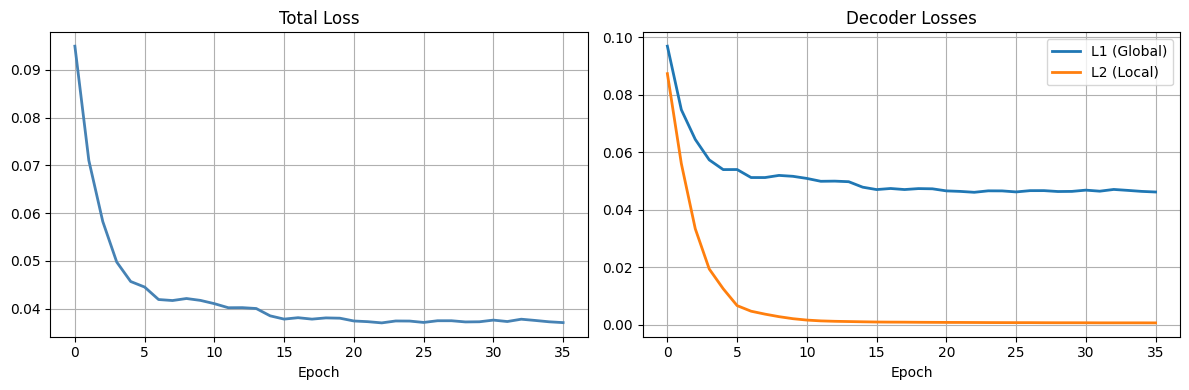

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['loss'], lw=2, color='steelblue')
ax[0].set_title('Total Loss'); ax[0].set_xlabel('Epoch'); ax[0].grid(True)
ax[1].plot(history['L1'], lw=2, label='L1 (Global)')
ax[1].plot(history['L2'], lw=2, label='L2 (Local)')
ax[1].set_title('Decoder Losses'); ax[1].set_xlabel('Epoch')
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


## 8. 평가

In [ ]:
S, L = get_scores(model, te_ld, CFG['device'])
y_pred, y_true, per_dim = detect(S, L, CFG['q'], CFG['low_q'])
show_metrics(det_metrics(y_true, y_pred, S.max(1)), diag_metrics(S, L))



── Detection ──────────────────────────
  Precision   : 1.0000
  Recall      : 0.1800
  F1          : 0.3051
  AUC         : 1.0000
── Diagnosis ──────────────────────────
  H@100%      : 1.0000
  H@150%      : 1.0000
  N@100%      : 1.0000
  N@150%      : 1.0000


## 9. 결과 시각화

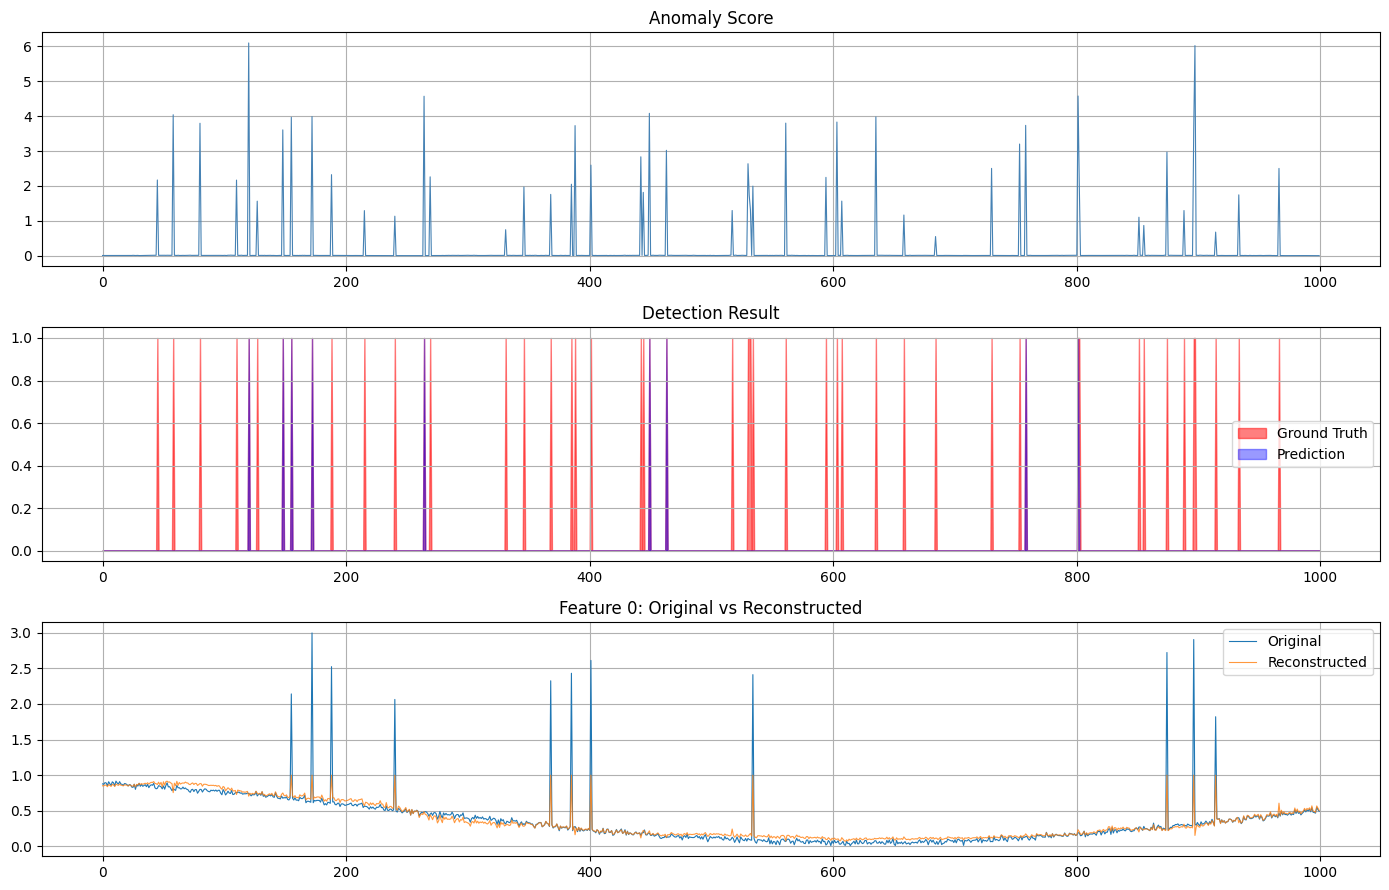

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
t = np.arange(len(S))

axes[0].plot(t, S.max(1), lw=0.8, color='steelblue')
axes[0].set_title('Anomaly Score'); axes[0].grid(True)

axes[1].fill_between(t, y_true, alpha=0.5, color='red',  label='Ground Truth')
axes[1].fill_between(t, y_pred, alpha=0.4, color='blue', label='Prediction')
axes[1].set_title('Detection Result'); axes[1].legend(); axes[1].grid(True)

model.eval()
recon = []
with torch.no_grad():
    for win, _ in te_ld:
        o1, *_ = model(win.to(CFG['device']))
        recon.append(o1.cpu().numpy()[:, -1, 0])
recon = np.concatenate(recon)
axes[2].plot(t, te_p[:len(t), 0], lw=0.8, label='Original')
axes[2].plot(t, recon[:len(t)],   lw=0.8, label='Reconstructed', alpha=0.8)
axes[2].set_title('Feature 0: Original vs Reconstructed')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()


## 10. 모델 저장

In [ ]:
torch.save(model.state_dict(), 'dtaad_weights.pt')
print('Saved → dtaad_weights.pt')


Saved → dtaad_weights.pt


---
## 11. 공개 데이터셋 사용 (선택)
주석 해제 후 Google Drive에 데이터를 올리고 실행하세요.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# DATA   = '/content/drive/MyDrive/datasets/SMD'
# entity = 'machine-1-1'
# tr_d = np.load(os.path.join(DATA, 'train',      f'{entity}.npy'))
# te_d = np.load(os.path.join(DATA, 'test',       f'{entity}.npy'))
# te_l = np.load(os.path.join(DATA, 'test_label', f'{entity}.npy'))
# if te_l.ndim == 1:
#     te_l = np.tile(te_l[:, None], (1, te_d.shape[1]))
# tr_l = np.zeros_like(tr_d)
# # → 이후 5번 셀과 동일하게 실행
